# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 2.  線性迴歸訓練資料、測試資料

80%  training data, 20%  testing data ==> 先利用此來驗證各種模型(演算法)的好壞及調好到最佳參數
之後可以利用由這個80%的訓練資料所得的模型後,拿100%資料re-train模型以得到最佳模型 (此model會更佳fit data)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
x = np.linspace(0, 5, 50)  #先產生一個0~5之前50個數字, 生成x
y = 1.2*x + 0.8 + 0.6*np.random.randn(50) #1.2斜率、0.8截距、加一個noise, 生成y

#丟到下面做資料切割，test_size=0.2測試切成20%，所以訓練資料有80%, random_state
#random_state:把資料集做隨機排序的意思，不給值的話，每次打亂順序就不同，給值的話，就會固定打亂成一個順序
#切割成 x_train, x_test, y_train, y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)
print(x_train)

[4.08163265 1.73469388 1.83673469 0.         2.75510204 3.36734694
 3.67346939 4.28571429 1.02040816 0.30612245 4.18367347 1.32653061
 4.69387755 0.20408163 3.87755102 3.97959184 0.51020408 4.3877551
 3.7755102  3.06122449 0.6122449  2.95918367 1.63265306 1.93877551
 5.         4.48979592 2.14285714 3.26530612 3.46938776 0.71428571
 2.24489796 1.12244898 2.04081633 0.91836735 4.89795918 2.85714286
 3.16326531 1.53061224 2.65306122 3.57142857]


In [7]:
y

array([0.69312128, 0.68289655, 0.17476377, 1.74896706, 1.82912978,
       1.84175008, 2.58138137, 1.71986126, 2.1848557 , 1.11349778,
       2.34380167, 2.47451243, 3.55062897, 2.05808236, 1.84079037,
       3.59970026, 2.34363768, 3.21284406, 2.95715707, 3.43306965,
       2.72261927, 4.01554621, 2.74409138, 3.1634949 , 4.60491447,
       3.40993533, 3.7987985 , 3.69766032, 3.09465034, 4.32933726,
       3.62677906, 4.33982589, 5.01122279, 5.37699301, 4.40994997,
       4.47321985, 5.03076406, 5.61058091, 5.50634291, 5.65312402,
       5.25323844, 6.73401878, 5.29581595, 6.12430409, 6.29495088,
       7.03202162, 6.90586931, 7.08373954, 6.73930359, 7.12843193])

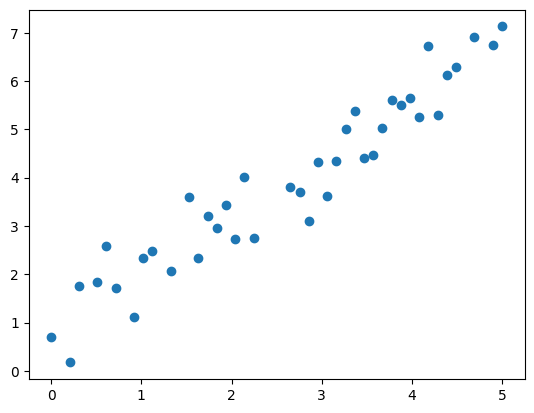

In [8]:
plt.scatter(x_train, y_train)

#### 用訓練資料來 fit 函數

記得現在我們只用 80% 的資料去訓練。

In [10]:
regr = LinearRegression()
X_train = x_train.reshape(-1,1)  #必需reshape成2維
regr.fit(X_train,y_train)
print('Coefficients(斜率): ', regr.coef_)   #拿來跟原本預設的1.2 斜率
print('interception(截距): ', regr.intercept_) #拿來跟原本預設的0.8 截距比對看看

Coefficients(斜率):  [1.1848485]
interception(截距):  0.8162703481820666


In [11]:
Y_train = regr.predict(X_train) #^y

In [12]:
#用MSE驗證上述的機器學習好不好
mse = np.sum((Y_train-y_train)**2) / len(y_train)
print(mse)

0.2774352225202921


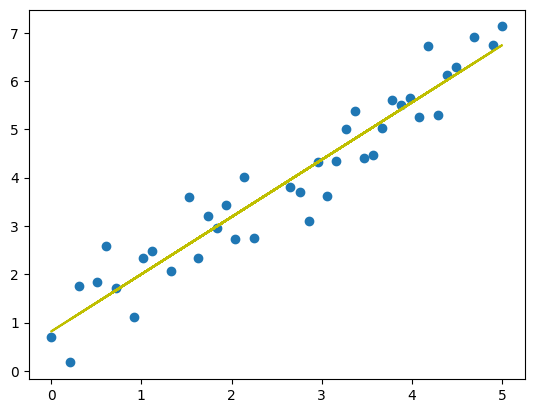

In [14]:
plt.scatter(x_train, y_train)   #把原始的點，散佈圖
plt.plot(x_train, Y_train, 'y')  #把和預估出來的線  做一個比較

#### test with test data (拿test資料去驗證結果)

In [ ]:
#方法一：用Linear Regression套件算出來
X_test = x_test.reshape(-1,1)
Y_test = regr.predict(X_test)

print(Y_test)

[2.26710525 2.50891107 1.29988198 1.78349362 6.25690123 0.93717326
 3.83884306 3.71794015 6.49870705 3.59703725]


$$\widehat{y}=xw+b=w_{1}x_{1}+b$$

In [21]:
#方法二：手動用公式算出，結果會同方法一
#Y=WX+b
W=regr.coef_
b=regr.intercept_
W*X_test+b


array([[2.26710525],
       [2.50891107],
       [1.29988198],
       [1.78349362],
       [6.25690123],
       [0.93717326],
       [3.83884306],
       [3.71794015],
       [6.49870705],
       [3.59703725]])

In [ ]:
#驗證測試集資料算的好不好(愈小愈準，愈接近零愈好)
mse = np.sum((Y_test-y_test)**2) / len(y_test)
print(mse)

0.4701388669901373


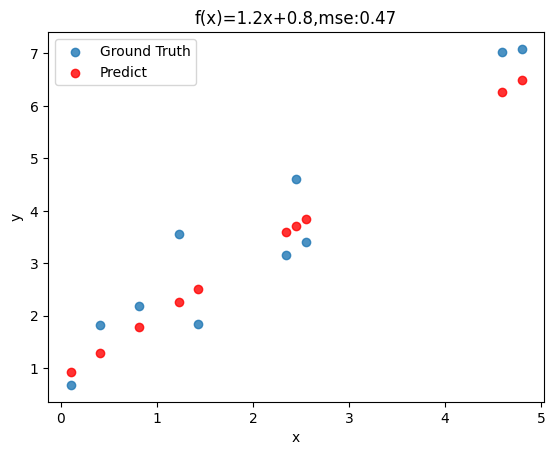

In [24]:
title='f(x)=1.2x+0.8'+',mse:'+str(round(mse,2))
plt.title(title)
plt.xlabel('x')
plt.ylabel('y')
#plt.grid(True)
plt.scatter(x_test, y_test,alpha=0.8,label='Ground Truth')  #原始點，藍色表示
plt.scatter(x_test, Y_test, c='r', alpha=0.8,label='Predict')  #預測點，紅色表示
plt.legend()